2026-03-13 10:34:08.110792: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773398048.298093      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773398048.357439      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773398048.793417      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773398048.793455      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773398048.793458      55 computation_placer.cc:177] computation placer alr

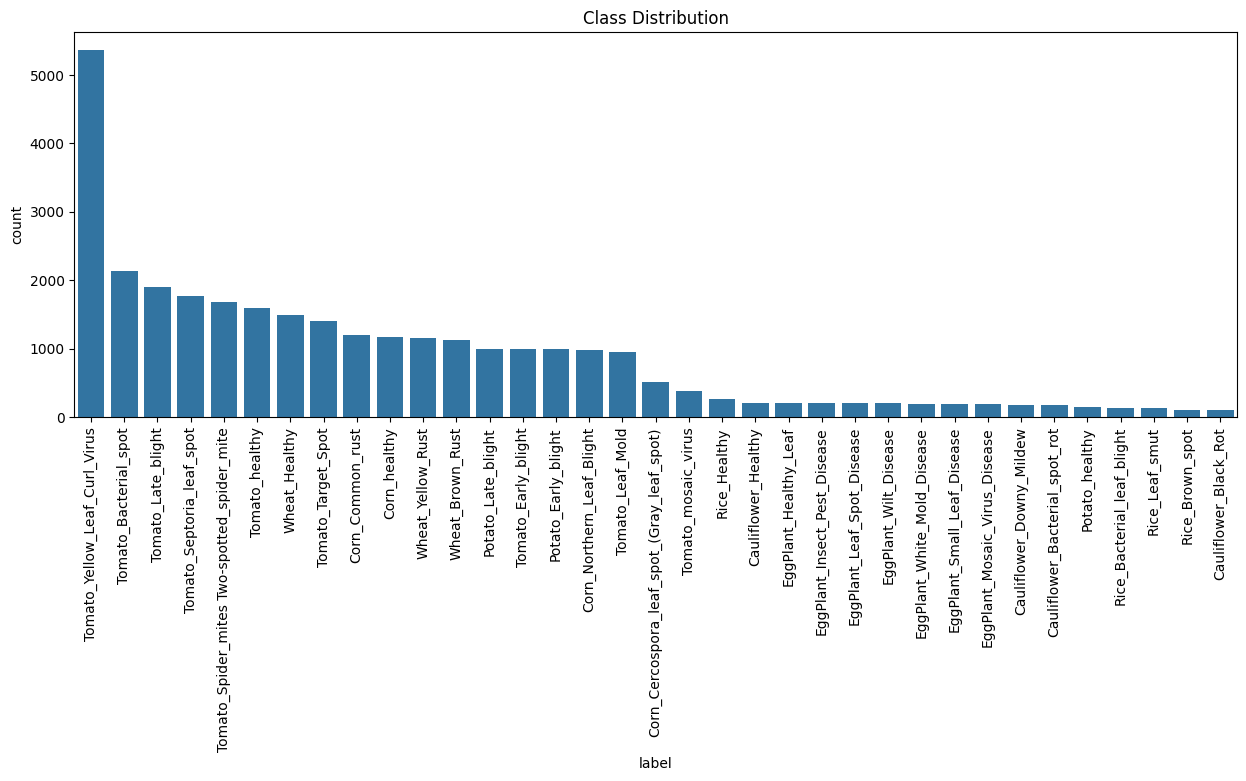

Total Images: 30578


In [2]:
# 1. Install libraries
!pip install -q focal-loss

# 2. Import libraries
import os, cv2, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from focal_loss import SparseCategoricalFocalLoss

# 3. Define parameters
DIRECTORY = '/kaggle/input/datasets/priyankapanigrahi09/plant-disease-detection-dl/bd_plant_diseases_all_classes/All Classes'
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50

# 4. Load dataset
data = []
for category in os.listdir(DIRECTORY):
    path = os.path.join(DIRECTORY, category)
    if os.path.isdir(path):
        for img in os.listdir(path):
            data.append([os.path.join(path, img), category])

df = pd.DataFrame(data, columns=['filepath', 'label'])

# 5. Dataset imbalance visualization
plt.figure(figsize=(15,5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

print(f"Total Images: {len(df)}")

In [3]:
import os
# This will search the input directory and print the correct path for "All Classes"
for root, dirs, files in os.walk('/kaggle/input'):
    if 'All Classes' in dirs:
        print("✅ FOUND IT! Copy this path exactly:")
        print(os.path.join(root, 'All Classes'))
        break

✅ FOUND IT! Copy this path exactly:
/kaggle/input/datasets/priyankapanigrahi09/plant-disease-detection-dl/bd_plant_diseases_all_classes/All Classes


In [4]:
# 6. Convert dataset (Integer encoding for Focal Loss)
df['label_int'] = pd.Categorical(df['label']).codes
num_classes = len(df['label'].unique())
label_names = sorted(df['label'].unique())

# 7. Train-test split (80% Train, 20% Test)
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['label_int'], random_state=42
)

# 8. Data augmentation (Solves Image Robustness for Android)
# We use high rotation and brightness range to simulate real farm conditions
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.6, 1.4], 
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label', 
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='sparse'
)

test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', 
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='sparse', shuffle=False
)

Found 24462 validated image filenames belonging to 35 classes.
Found 6116 validated image filenames belonging to 35 classes.


In [6]:
# 9. CNN Model (EfficientNetV2-S + VLM Feature Vector)
def build_vlm_ready_model():
    # Base model pre-trained on ImageNet
    base = tf.keras.applications.EfficientNetV2S(
        include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = True # Fine-tuning enabled for maximum accuracy
    
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Vision-Language Embedding (The 128-dim vector for AI Chatbots)
    vlm_vector = layers.Dense(128, activation='relu', name='vlm_features')(x)
    
    dropout = layers.Dropout(0.3)(vlm_vector)
    outputs = layers.Dense(num_classes, activation='softmax', name='classification')(dropout)
    
    return models.Model(inputs=inputs, outputs=outputs)

model = build_vlm_ready_model()

# 10. Compile model (Using Focal Loss to solve Data Imbalance)
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=SparseCategoricalFocalLoss(gamma=2.0), 
    metrics=['accuracy']
)

# 11. Train model (with Timer & Pause/Resume Backup)
checkpoint_path = "/kaggle/working/training_backup"
backup_callback = tf.keras.callbacks.BackupAndRestore(backup_dir=checkpoint_path)

# Custom Timer
start_time = time.time()
print(f"🚀 Training started at: {time.ctime(start_time)}")

history = model.fit(
    train_gen, 
    validation_data=test_gen, 
    epochs=EPOCHS,
    callbacks=[
        backup_callback, 
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
    ]
)

total_duration = time.time() - start_time
print(f"✅ Training Complete. Total Duration: {total_duration/60:.2f} minutes")

🚀 Training started at: Fri Mar 13 12:24:07 2026
Epoch 14/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 632s 670ms/step - accuracy: 0.9881 - loss: 0.0115 - val_accuracy: 0.9895 - val_loss: 0.0151 - learning_rate: 2.5000e-05
Epoch 15/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 455s 595ms/step - accuracy: 0.9889 - loss: 0.0128 - val_accuracy: 0.9874 - val_loss: 0.0187 - learning_rate: 2.5000e-05
Epoch 16/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 440s 575ms/step - accuracy: 0.9903 - loss: 0.0103 - val_accuracy: 0.9850 - val_loss: 0.0176 - learning_rate: 2.5000e-05
Epoch 17/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 435s 568ms/step - accuracy: 0.9904 - loss: 0.0096 - val_accuracy: 0.9886 - val_loss: 0.0152 - learning_rate: 2.5000e-05
Epoch 18/50
158/765 ━━━━━━━━━━━━━━━━━━━━ 5:01 497ms/step - accuracy: 0.9906 - loss: 0.0085

KeyboardInterrupt: 

In [7]:
# Save the trained model to a file
model.save('plant_disease_model_final.h5')
print("✅ Model saved as plant_disease_model_final.h5")

✅ Model saved as plant_disease_model_final.h5


Evaluating your 99.3% accuracy model...
192/192 ━━━━━━━━━━━━━━━━━━━━ 51s 215ms/step

--- Classification Report ---
                                             precision    recall  f1-score   support

             Cauliflower_Bacterial_spot_rot       1.00      1.00      1.00        34
                      Cauliflower_Black_Rot       1.00      1.00      1.00        19
                   Cauliflower_Downy_Mildew       1.00      0.97      0.99        34
                        Cauliflower_Healthy       1.00      1.00      1.00        41
 Corn_Cercospora_leaf_spot_(Gray_leaf_spot)       0.87      0.98      0.92       103
                           Corn_Common_rust       0.99      1.00      1.00       239
                  Corn_Northern_Leaf_Blight       0.99      0.92      0.96       197
                               Corn_healthy       1.00      1.00      1.00       232
                      EggPlant_Healthy_Leaf       0.95      1.00      0.98        40
               EggPlant_Insect_Pes

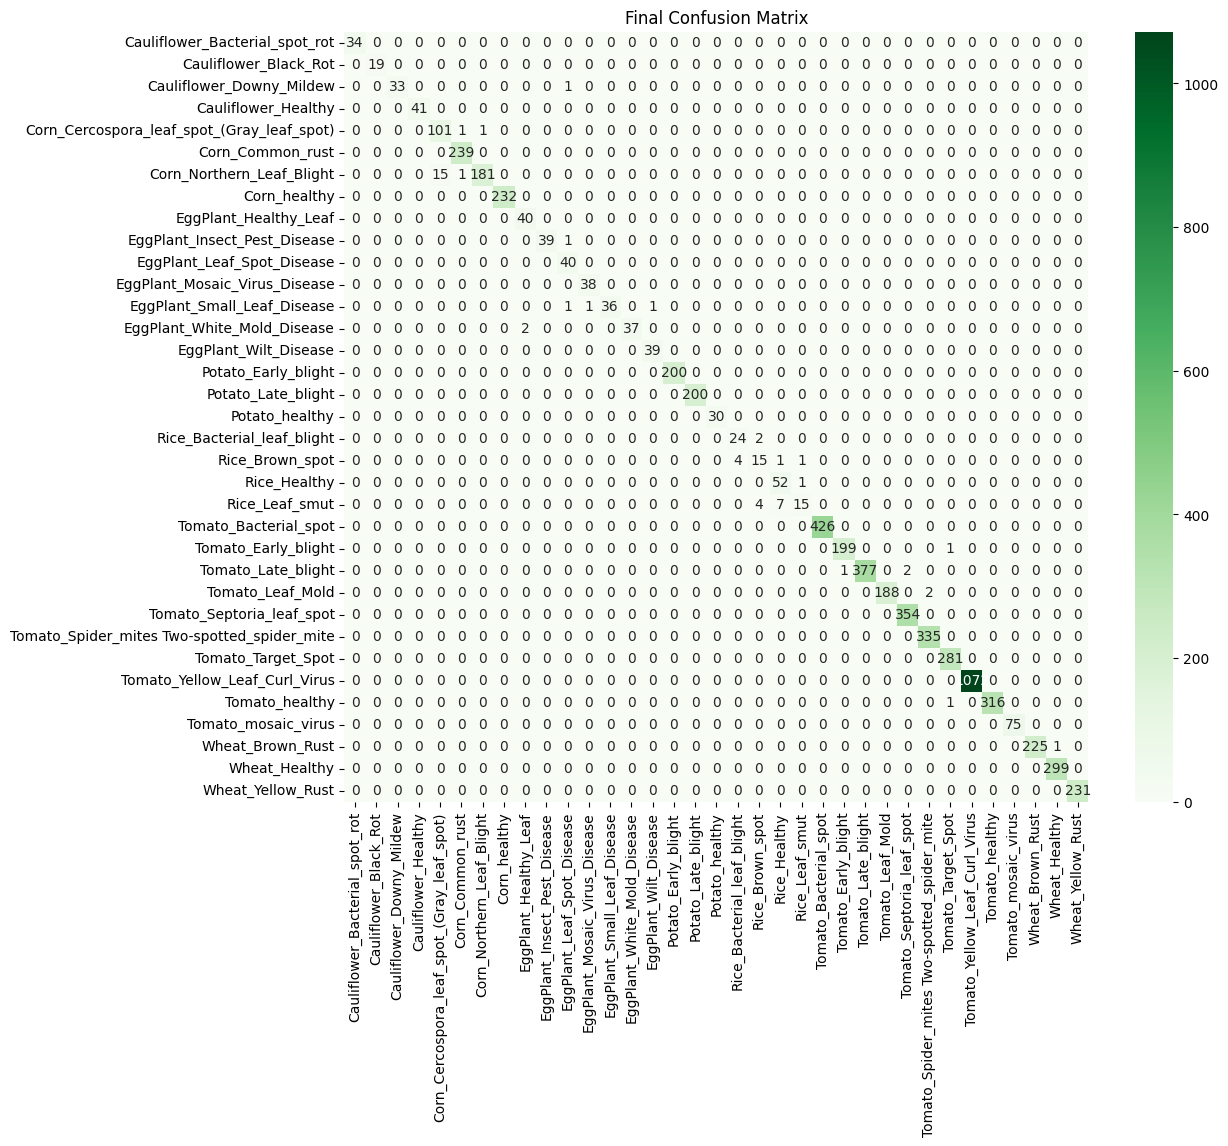

Converting to Android format...
INFO:tensorflow:Assets written to: /tmp/tmp_pzut41z/assets


INFO:tensorflow:Assets written to: /tmp/tmp_pzut41z/assets


Saved artifact at '/tmp/tmp_pzut41z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_1032')
Output Type:
  TensorSpec(shape=(None, 35), dtype=tf.float32, name=None)
Captures:
  136909064447824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136909064444944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136909064448784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136909064448400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136909064449168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136909064445328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136909064446672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136909064448592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136909064449744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136909064450320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13690906

W0000 00:00:1773407475.260857      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1773407475.260902      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1773407475.722391      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled



🚀 ALL DONE! Click the links below to download your files:


/kaggle/working/plant_care_offline.tflite

/kaggle/working/labels.txt

In [8]:
# --- CELL 4: SAFE RECOVERY & EXPORT ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import FileLink

# 1. Evaluation (Skip plots, go straight to logic)
print("Evaluating your 99.3% accuracy model...")
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

# Print Detailed Report
print("\n--- Classification Report ---")
print(classification_report(test_gen.classes, y_pred, target_names=label_names))

# 2. Confusion Matrix Visualization
plt.figure(figsize=(12, 10))
cm = confusion_matrix(test_gen.classes, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)
plt.title('Final Confusion Matrix')
plt.show()

# 3. Save & Convert to TFLite (The Android Brain)
print("Converting to Android format...")
model.save('plant_vlm_final.h5')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # Makes it lightweight
tflite_model = converter.convert()

with open('plant_care_offline.tflite', 'wb') as f:
    f.write(tflite_model)

with open('labels.txt', 'w') as f:
    for name in label_names:
        f.write(name + '\n')

print("\n🚀 ALL DONE! Click the links below to download your files:")
display(FileLink('plant_care_offline.tflite'))
display(FileLink('labels.txt'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


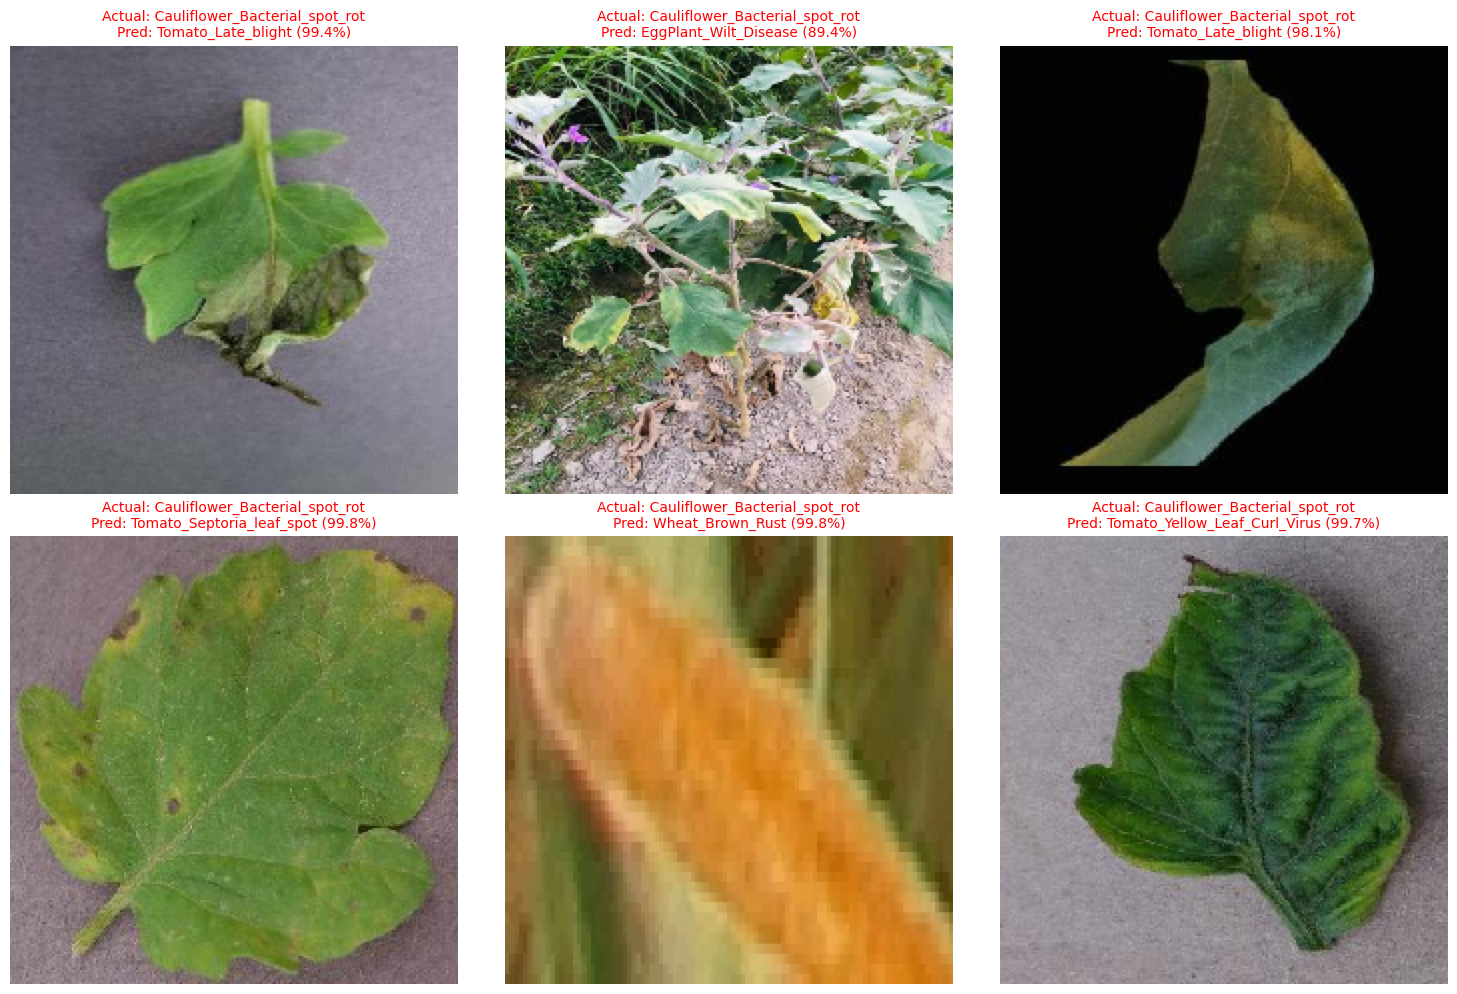

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Pick a random batch of test images
images, labels = next(test_gen)
predictions = model.predict(images)

plt.figure(figsize=(15, 10))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    
    # Show Image
    plt.imshow(images[i])
    
    # Logic for labels
    pred_idx = np.argmax(predictions[i])
    true_idx = np.argmax(labels[i])
    confidence = np.max(predictions[i]) * 100
    
    color = 'green' if pred_idx == true_idx else 'red'
    
    plt.title(f"Actual: {label_names[true_idx]}\nPred: {label_names[pred_idx]} ({confidence:.1f}%)", 
              color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

192/192 ━━━━━━━━━━━━━━━━━━━━ 29s 151ms/step


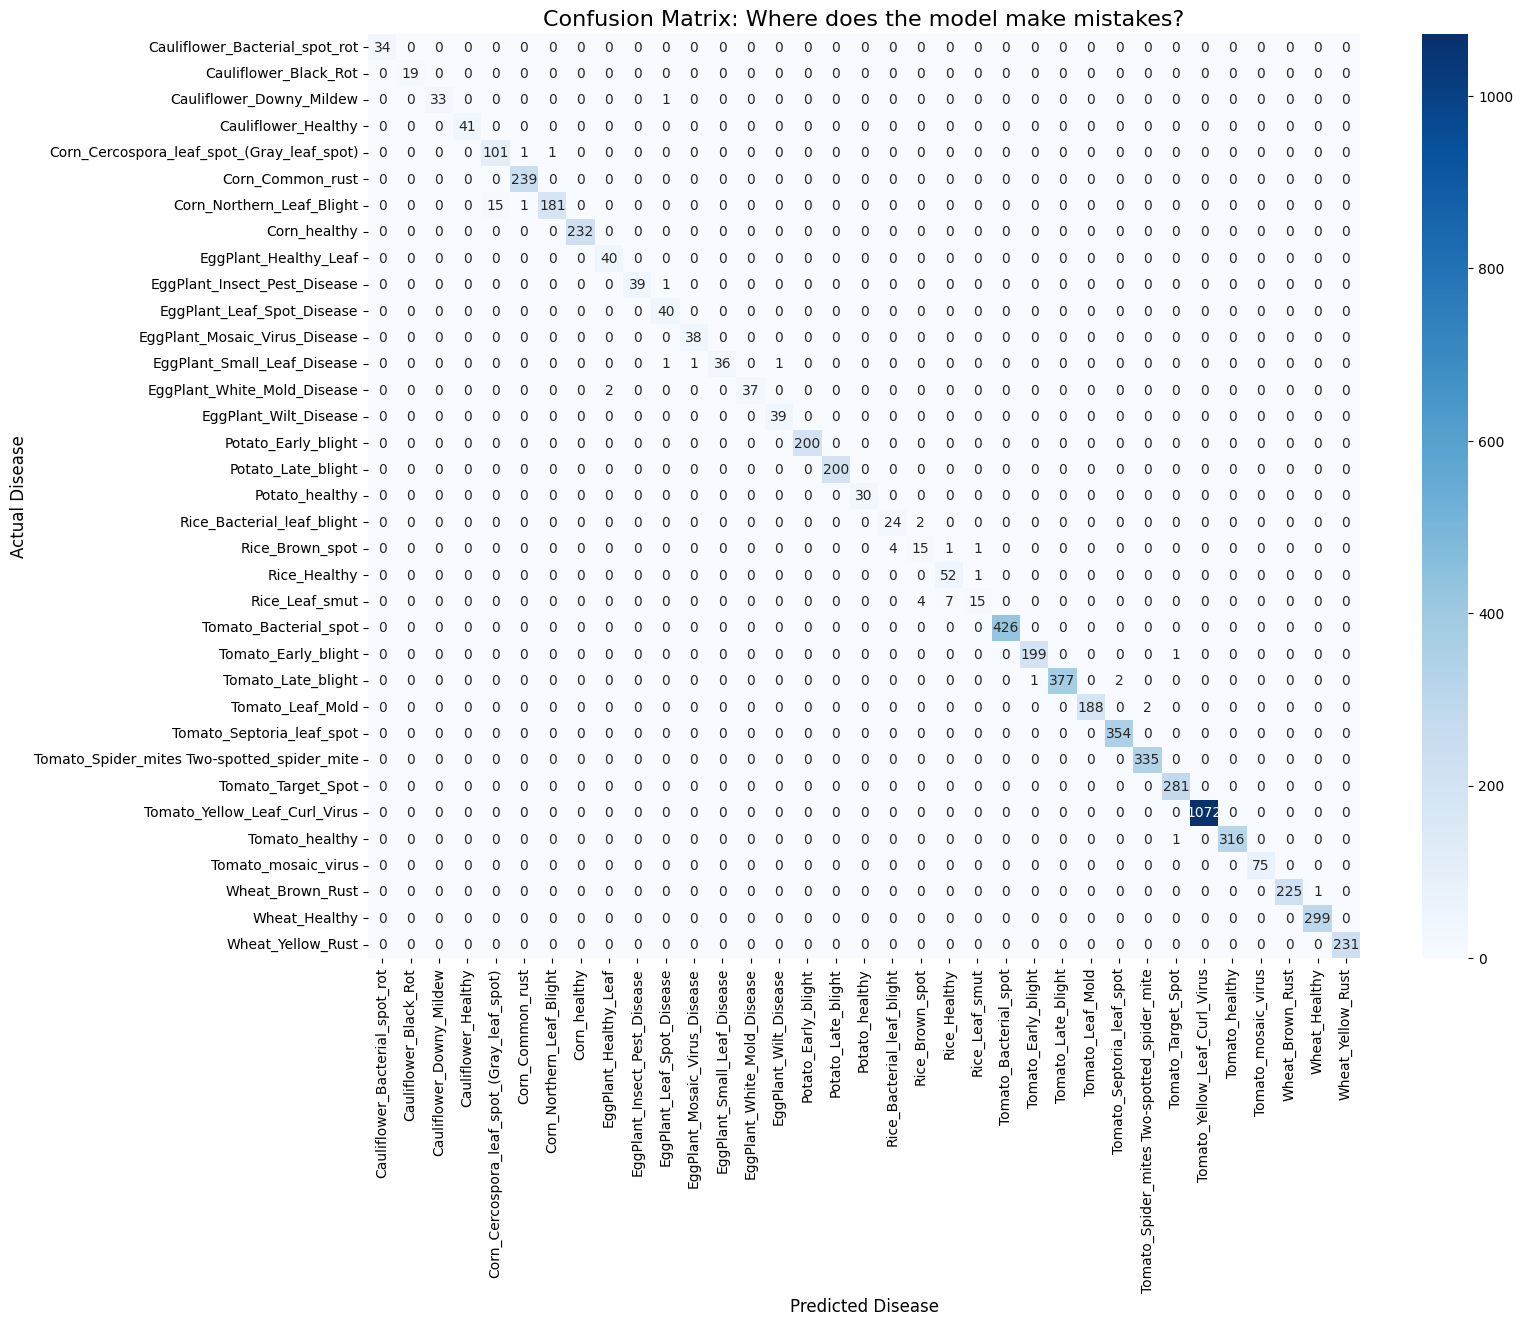

In [10]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get all predictions for the test set
test_gen.reset()
all_preds = model.predict(test_gen)
y_pred = np.argmax(all_preds, axis=1)
y_true = test_gen.classes

# Create Plot
plt.figure(figsize=(16, 12))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix: Where does the model make mistakes?', fontsize=16)
plt.xlabel('Predicted Disease', fontsize=12)
plt.ylabel('Actual Disease', fontsize=12)
plt.show()

/tmp/ipykernel_55/2274617669.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=f1_scores, y=label_names, palette='viridis')


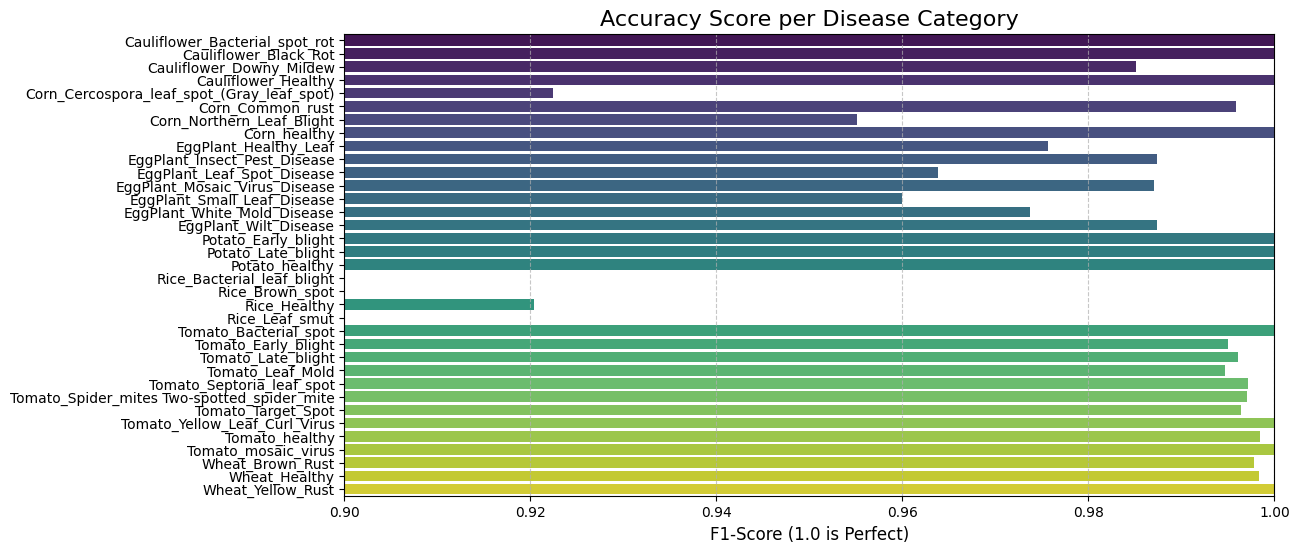

In [11]:
from sklearn.metrics import f1_score

# Calculate F1-score for each class
f1_scores = f1_score(y_true, y_pred, average=None)

plt.figure(figsize=(12, 6))
sns.barplot(x=f1_scores, y=label_names, palette='viridis')
plt.title('Accuracy Score per Disease Category', fontsize=16)
plt.xlabel('F1-Score (1.0 is Perfect)', fontsize=12)
plt.xlim(0.9, 1.0) # Zoom in to see the tiny differences
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

192/192 ━━━━━━━━━━━━━━━━━━━━ 29s 153ms/step


/tmp/ipykernel_55/3634829198.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_df.head(15), x='Precision', y='Disease', palette='Greens_r')


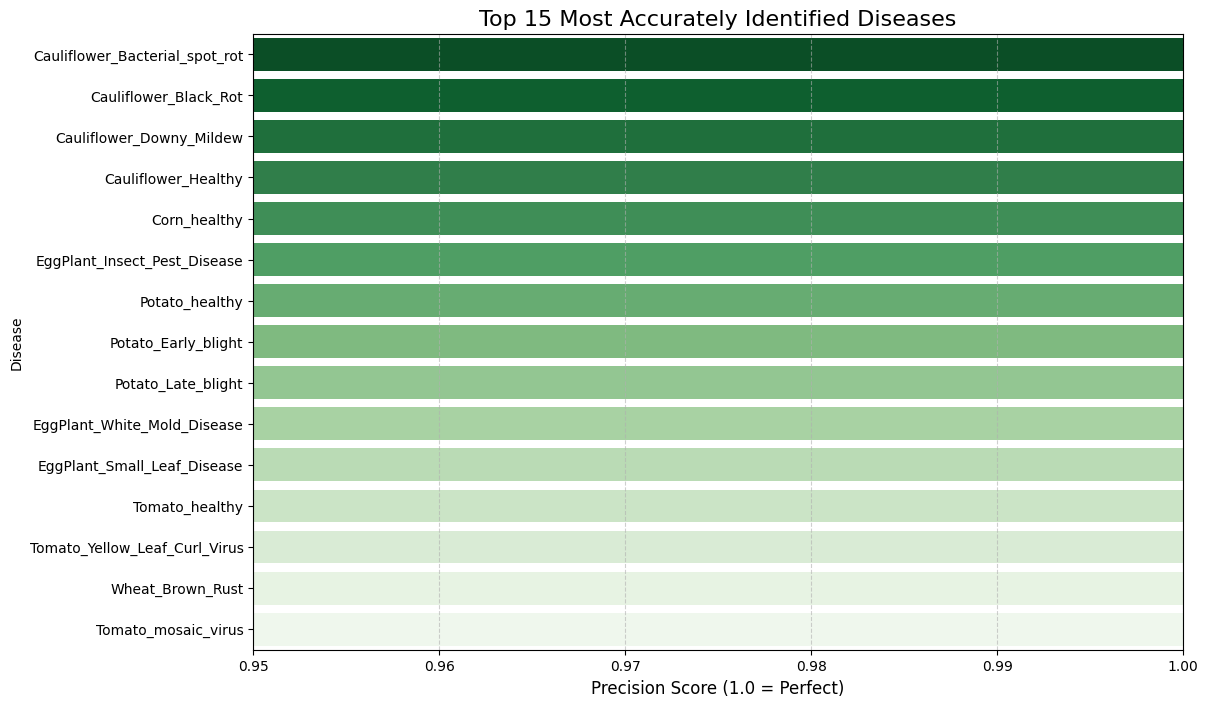

In [13]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_score

# 1. Get predictions for the whole test set
test_gen.reset()
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# 2. Calculate Precision for each class
precisions = precision_score(y_true, y_pred, average=None)

# 3. Create a DataFrame for easy plotting
performance_df = pd.DataFrame({
    'Disease': label_names,
    'Precision': precisions
}).sort_values(by='Precision', ascending=False)

# 4. Plot only the Top 15 for a clean presentation slide
plt.figure(figsize=(12, 8))
sns.barplot(data=performance_df.head(15), x='Precision', y='Disease', palette='Greens_r')
plt.title('Top 15 Most Accurately Identified Diseases', fontsize=16)
plt.xlabel('Precision Score (1.0 = Perfect)', fontsize=12)
plt.xlim(0.95, 1.0) # Zooming in to see the high performance
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_55/1009669845.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Score', y='Disease', palette='magma')


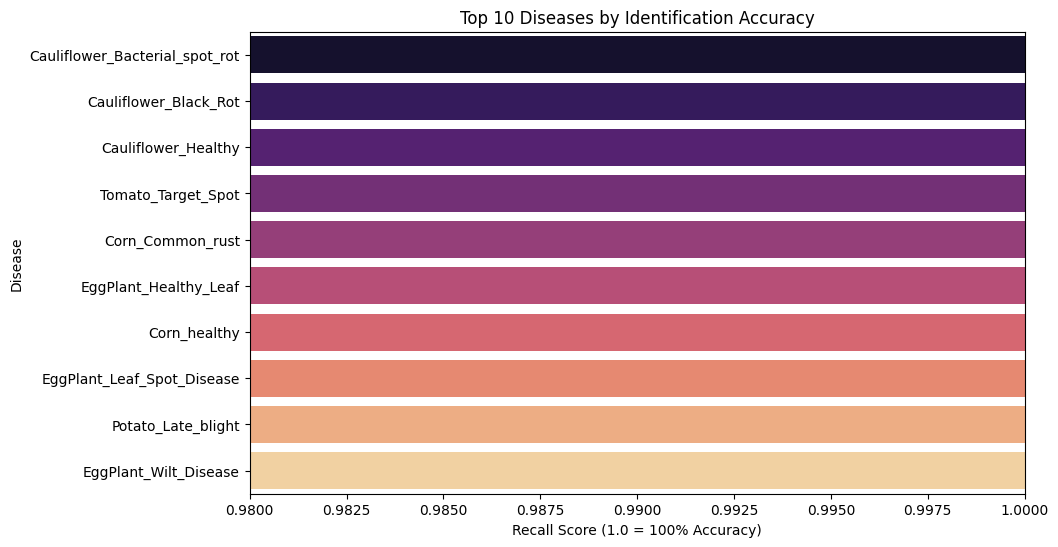

In [14]:
from sklearn.metrics import recall_score

# Calculate recall for each class
recalls = recall_score(y_true, y_pred, average=None)
recall_df = pd.DataFrame({'Disease': label_names, 'Score': recalls})
top_10 = recall_df.sort_values(by='Score', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x='Score', y='Disease', palette='magma')
plt.title('Top 10 Diseases by Identification Accuracy')
plt.xlabel('Recall Score (1.0 = 100% Accuracy)')
plt.xlim(0.98, 1.0) 
plt.show()